In [1]:
# 1. Instalar la librería oficial de YOLOv8
!pip install ultralytics

from ultralytics import YOLO
import os
from IPython.display import Image, display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import os

# Crear la carpeta de destino si no existe
os.makedirs('datasets/wildlife_data', exist_ok=True)

# Descomprimir el archivo
# El comando !unzip es una herramienta de sistema de Linux muy rápida
!unzip -q /content/archive.zip -d /content/datasets/wildlife_data

In [4]:
import yaml

# Definimos la configuración basada en tu estructura de carpetas
data_config = {
    'path': '/content/datasets/wildlife_data/final_data', # Ruta raíz donde están train/val
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',   # Opcional, pero bueno tenerlo
    'nc': 4,                 # Verifica si son 4 clases en tu dataset
    'names': ['Elephant', 'Lion', 'Tiger', 'Zebra'] # Asegúrate que el orden coincida con el dataset
}

# Guardamos el archivo en la raíz de Colab para fácil acceso
with open('/content/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("Archivo data.yaml creado con éxito.")

Archivo data.yaml creado con éxito.


In [5]:
from ultralytics import YOLO

# 1. Cargamos el modelo preentrenado de YOLOv8 (esto es Transfer Learning)
model = YOLO('yolov8n.pt')

# 2. Iniciamos el entrenamiento
results = model.train(
    data='/content/data.yaml', # El archivo que acabamos de crear
    epochs=50,                 # Requisito del taller
    imgsz=640,                 # Resolución estándar
    batch=16,                  # Tamaño del lote
    name='entrenamiento_wildlife' # Nombre de la carpeta de resultados
)

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=entrenamiento_wildlife, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [6]:
import yaml

data_config = {
    'path': '/content/datasets/wildlife_data/final_data',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 4,
    'names': ['buffalo', 'elephant', 'rhino', 'zebra']
}

with open('/content/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

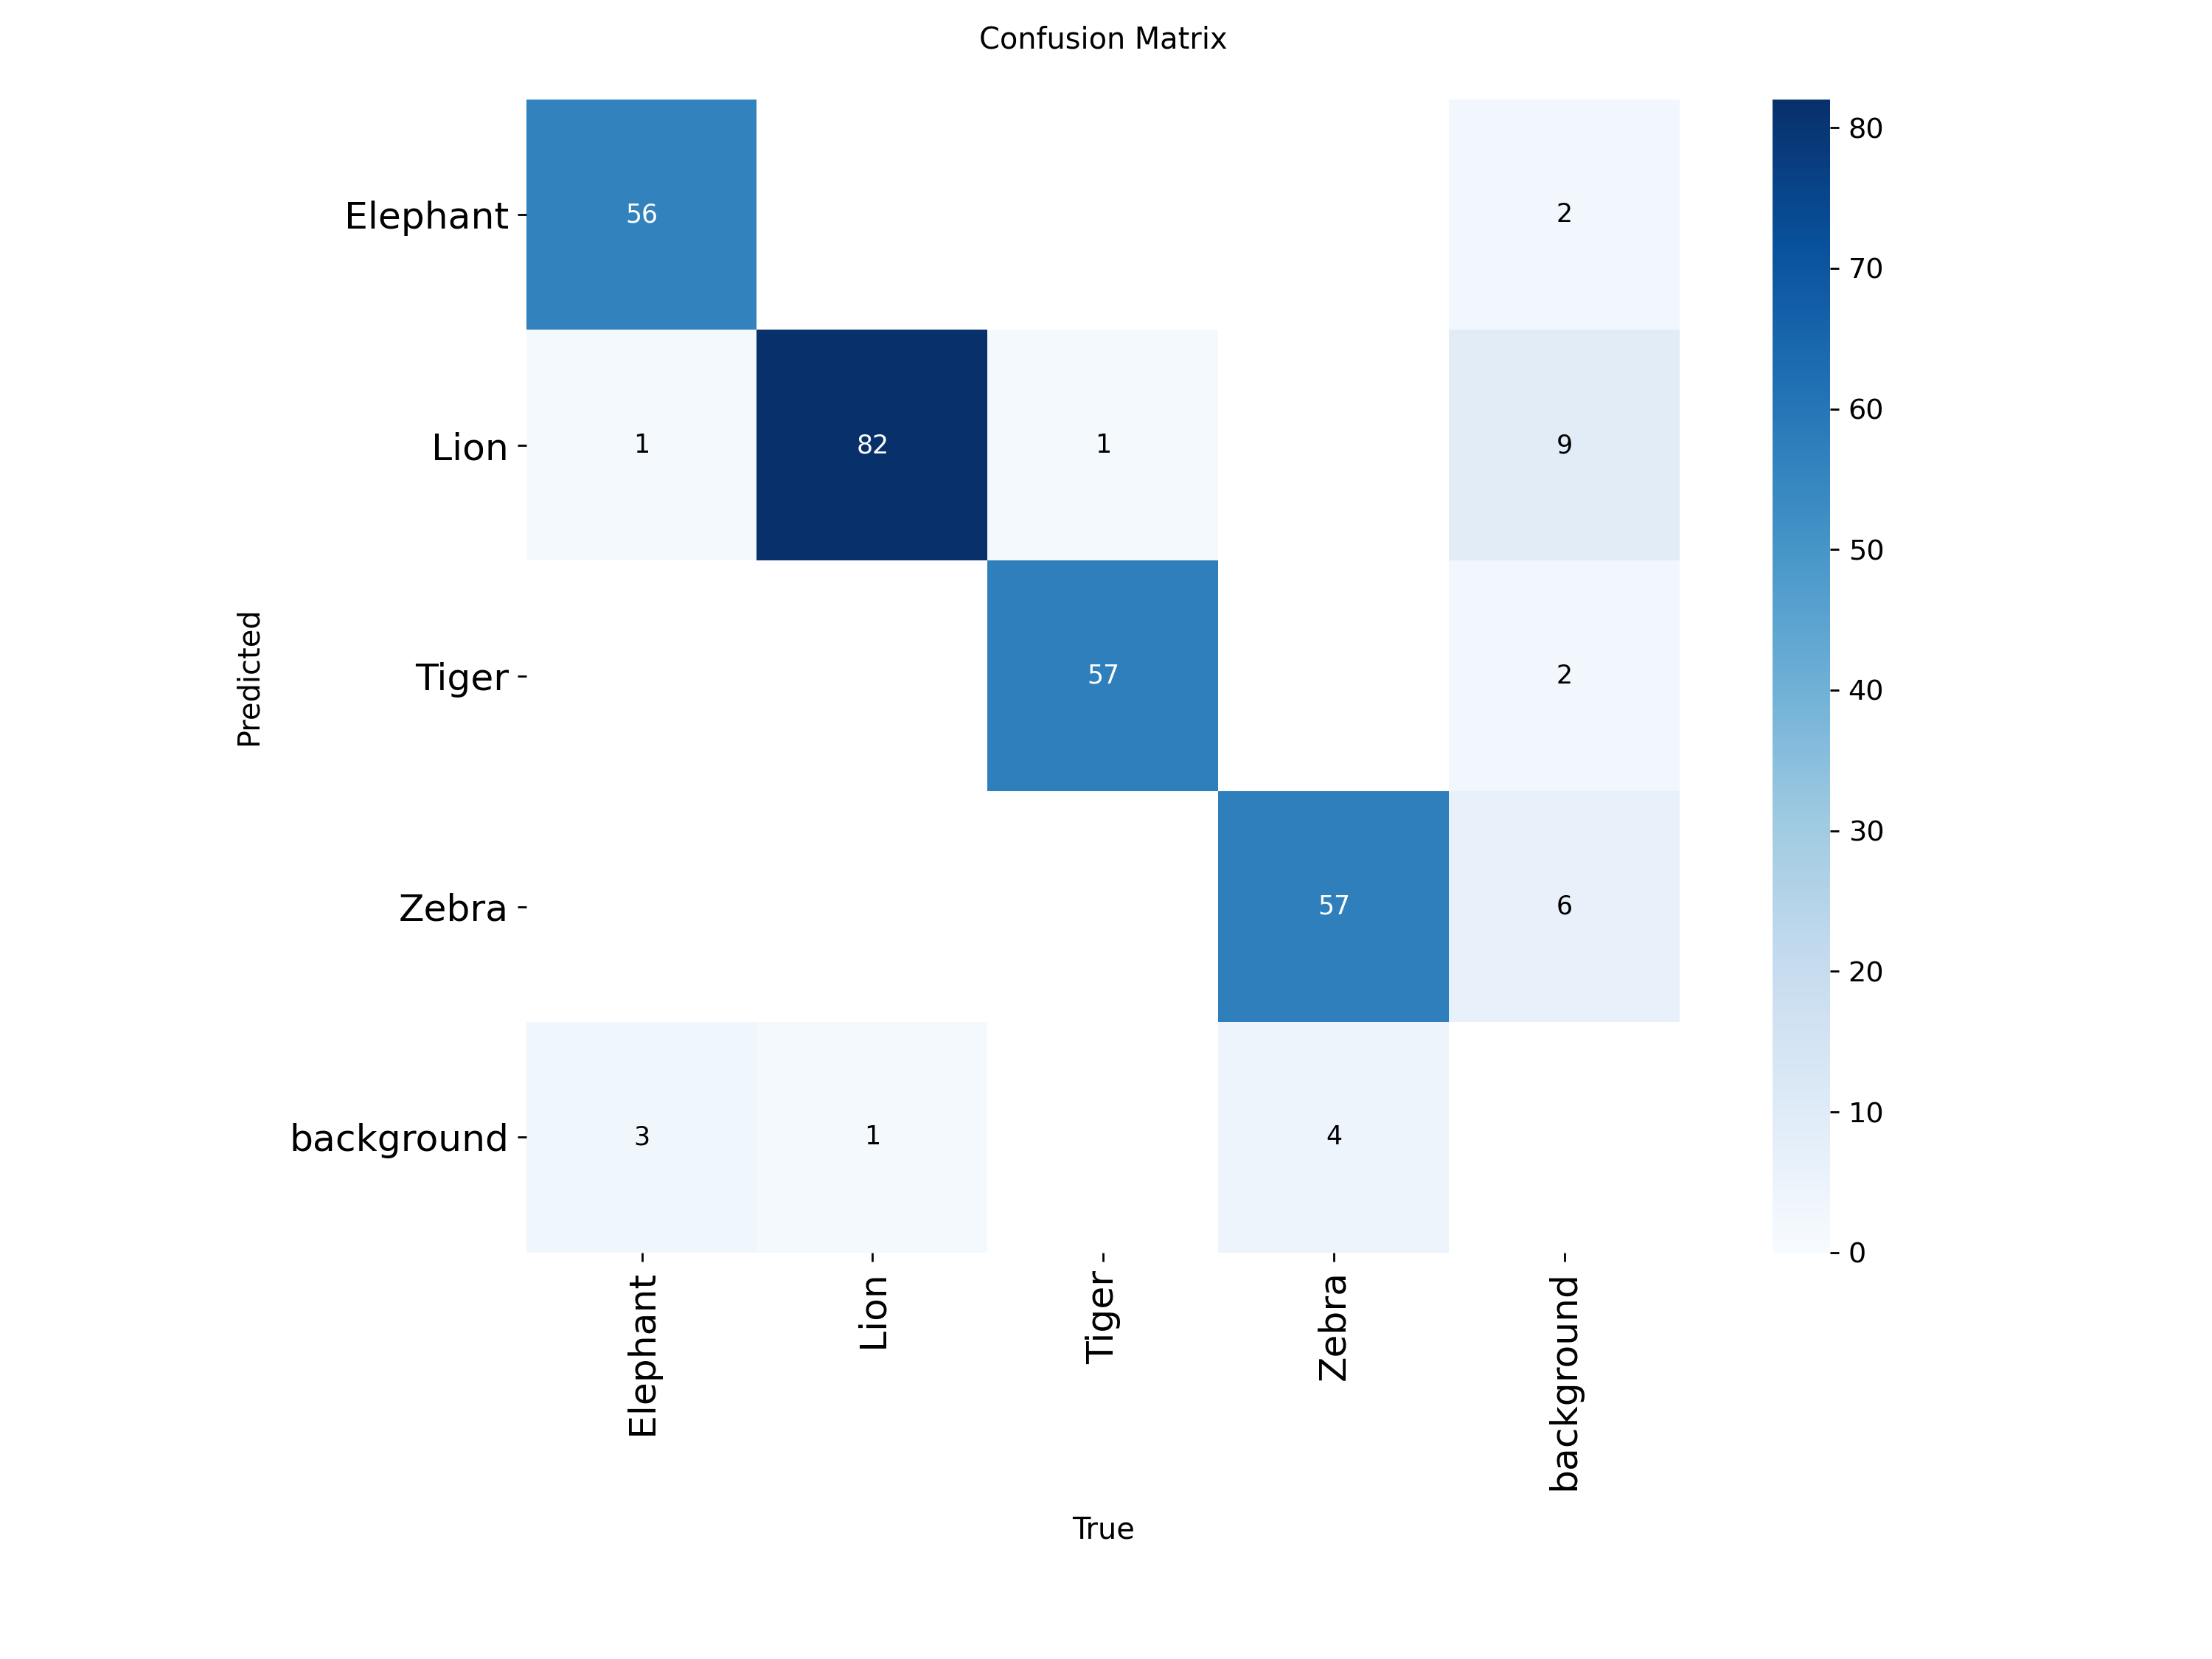

In [7]:
# Mostrar la matriz de confusión generada automáticamente
from IPython.display import Image, display
display(Image(filename='runs/detect/entrenamiento_wildlife/confusion_matrix.png'))


image 1/1 /content/test_animal_2.jpg: 384x640 1 Zebra, 12.4ms
Speed: 3.1ms preprocess, 12.4ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


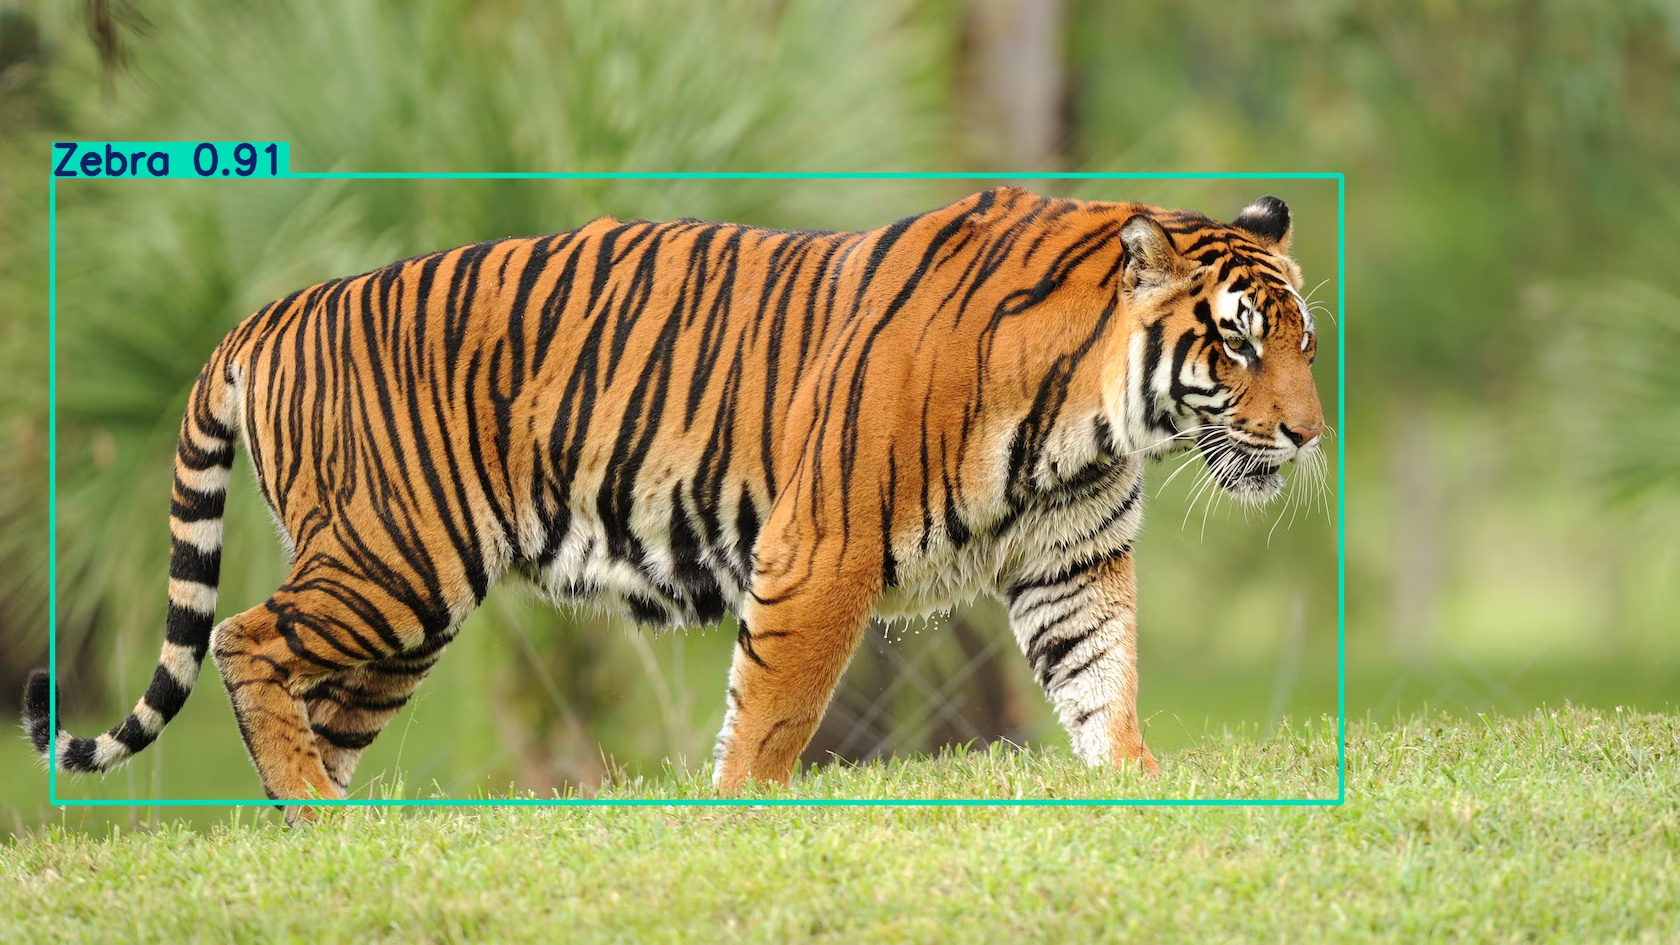

In [13]:
# Cargar el mejor modelo (asegúrate de que la ruta sea la correcta tras terminar el entrenamiento)
model_best = YOLO('/content/runs/detect/entrenamiento_wildlife/weights/best.pt')

# Ejecutar predicción con el nombre de TU imagen
# Cambia 'test_animal.jpg' por el nombre real de tu archivo
results = model_best.predict(source='/content/test_animal_2.jpg', save=True)

# Visualizar el resultado
# YOLO crea una carpeta nueva para cada predicción (predict, predict2, etc.)
# Verifica en el panel izquierdo dentro de runs/detect/ cuál es la carpeta más reciente
display(Image(filename='/content/runs/detect/predict/test_animal_2.jpg'))

In [14]:
# Ver el mapeo que el modelo guardó durante el entrenamiento fallido
print(model.names)

{0: 'Elephant', 1: 'Lion', 2: 'Tiger', 3: 'Zebra'}


In [15]:
import yaml

data_config = {
    'path': '/content/datasets/wildlife_data/final_data',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 4,
    'names': {
        0: 'Elephant',
        1: 'Lion',
        2: 'Tiger',
        3: 'Zebra'
    }
}

with open('/content/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

In [16]:
# Borrar caché anterior
!rm -f /content/datasets/wildlife_data/final_data/train/labels.cache
!rm -f /content/datasets/wildlife_data/final_data/valid/labels.cache

from ultralytics import YOLO

# Cargar modelo base
model = YOLO('yolov8n.pt')

# Entrenar con el mapeo correcto
model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=640,
    name='wildlife_final_corregido'
)

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wildlife_final_corregido, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bbc40b78500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [18]:
from ultralytics import YOLO
from IPython.display import Image, display

# Cargamos el archivo 'best.pt' de la carpeta del entrenamiento corregido
model_corregido = YOLO('/content/runs/detect/wildlife_final_corregido/weights/best.pt')


image 1/1 /content/test_animal_5.jpg: 640x384 1 Lion, 41.7ms
Speed: 3.0ms preprocess, 41.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict-2
Mostrando resultado desde: /content/runs/detect/predict-2/test_animal_5.jpg


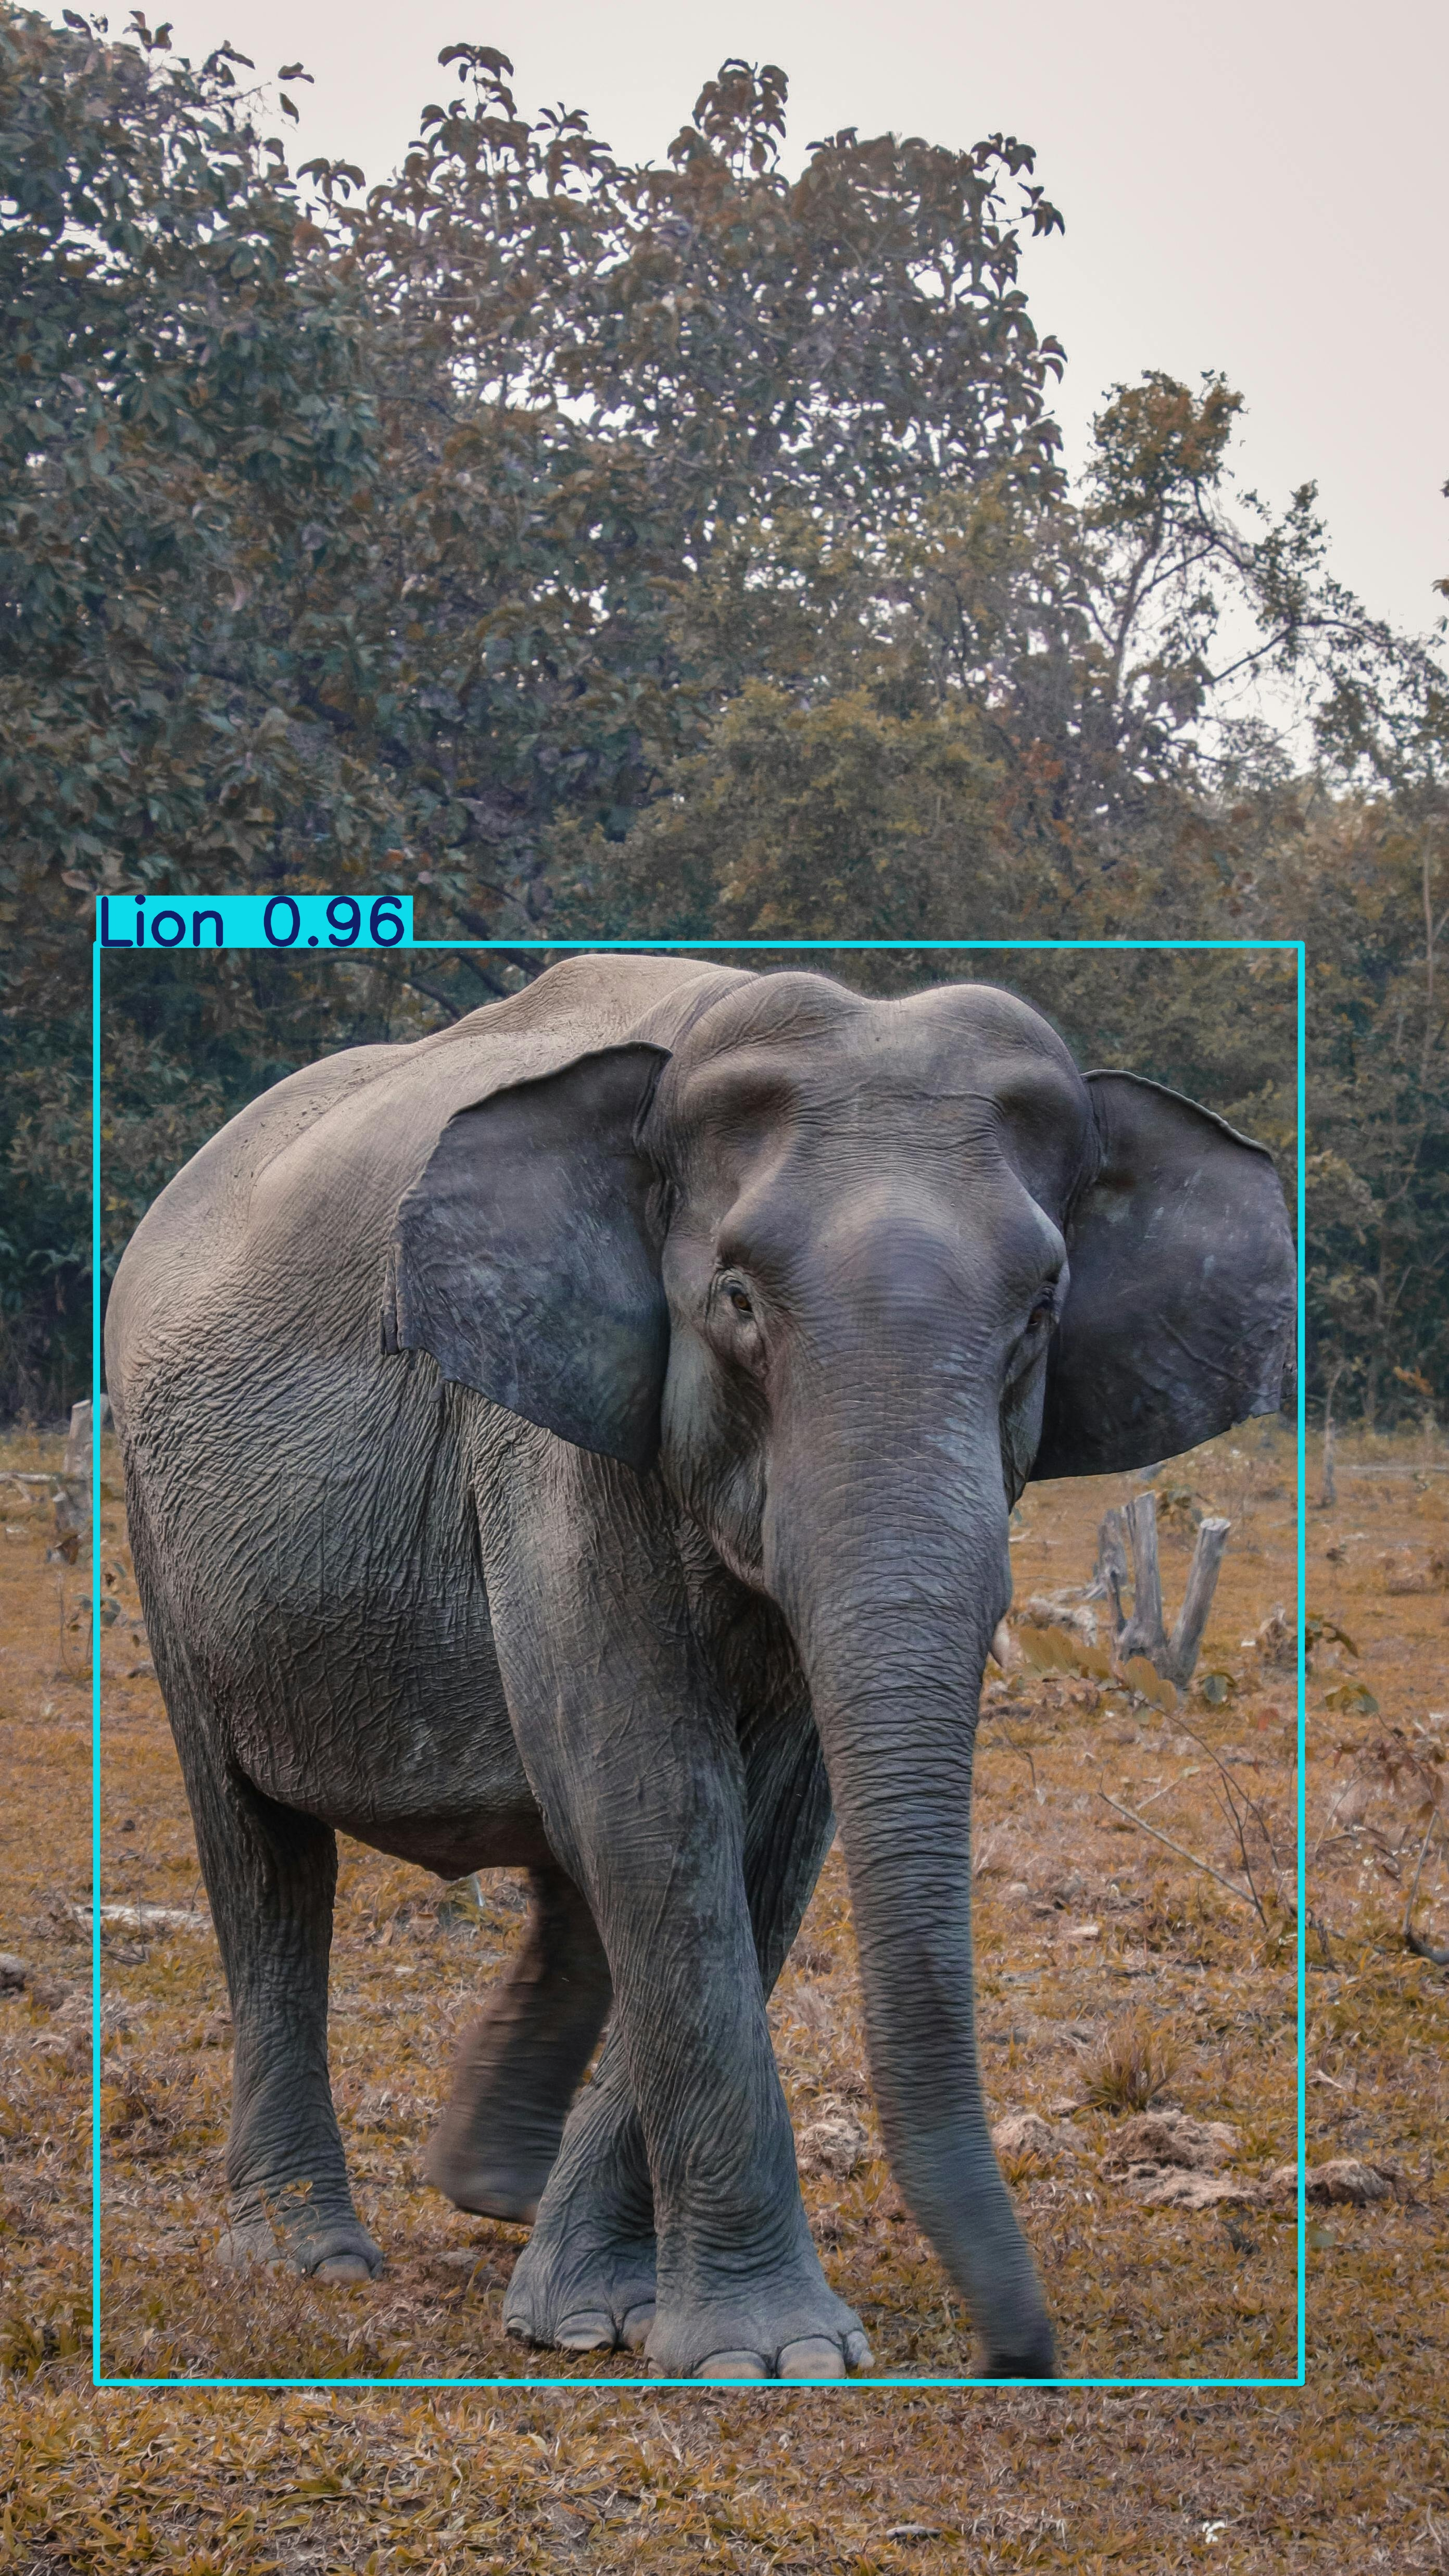

In [32]:
import os

# 1. Realizar la predicción
results = model_corregido.predict(source='/content/test_animal_5.jpg', save=True)

# 2. Obtener la ruta de la carpeta donde se guardó (ej: runs/detect/predict...)
res_save_dir = results[0].save_dir

# 3. Listar los archivos en esa carpeta para encontrar la imagen procesada
archivos_en_predict = os.listdir(res_save_dir)
imagen_procesada = [f for f in archivos_en_predict if f.endswith(('.jpg', '.png', '.jpeg'))][0]

# 4. Mostrar la imagen con la ruta dinámica
ruta_final = os.path.join(res_save_dir, imagen_procesada)
print(f"Mostrando resultado desde: {ruta_final}")
display(Image(filename=ruta_final))

In [24]:
# 1. Ejecutar validación (asegúrate de que model_corregido esté cargado)
metrics = model_corregido.val()

# 2. Extraer valores usando las propiedades directas del objeto
map50 = metrics.box.map50  # mAP @ 0.5
map95 = metrics.box.map    # mAP @ 0.5:0.95
precision = metrics.box.mp # Mean Precision
recall = metrics.box.mr    # Mean Recall

print("--- MÉTRICAS FINALES PARA EL TALLER ---")
print(f"mAP@0.5:   {map50:.4f}")
print(f"mAP@0.5:0.95: {map95:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1616.2±512.6 MB/s, size: 307.1 KB)
val: Scanning /content/datasets/wildlife_data/final_data/valid/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 52.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.9it/s 3.5s
                   all        150        262      0.954       0.94      0.973      0.843
              Elephant         38         60      0.945      0.859       0.93      0.834
                  Lion         43         83      0.927      0.976      0.988      0.821
                 Tiger         42         58          1      0.991      0.995      0.927
                 Zebra         28         61      0.943      0.934      0.979       0.79
Speed: 2.4ms preprocess, 3.8ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /co